In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 15
EPOCHS_FINE = 20

CLASSES = ["benign", "malignant", "normal"]

In [2]:
possible_processed_paths = [
    Path("/kaggle/working/processed"),
    Path("/content/processed"),
    Path("processed"),
    Path("../processed"),
    Path("../data/processed"),
    Path("data/processed")
]

processed_path = None

for path in possible_processed_paths:
    if (path / "train.csv").exists() and (path / "val.csv").exists() and (path / "test.csv").exists():
        processed_path = path
        break

if processed_path is None:
    raise FileNotFoundError(
        "No se han encontrado train.csv, val.csv y test.csv. "
        "Revisa la ruta de la carpeta processed."
    )

output_path = Path("transfer_learning_outputs")
models_path = output_path / "models"
figures_path = output_path / "figures"
metrics_path = output_path / "metrics"

for p in [output_path, models_path, figures_path, metrics_path]:
    p.mkdir(parents=True, exist_ok=True)

print("Carpeta processed:", processed_path)
print("Carpeta de salida:", output_path)

Carpeta processed: ..\data\processed
Carpeta de salida: transfer_learning_outputs


In [3]:
train_df = pd.read_csv(processed_path / "train.csv")
val_df = pd.read_csv(processed_path / "val.csv")
test_df = pd.read_csv(processed_path / "test.csv")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribución train:")
print(train_df["class"].value_counts())

print("\nDistribución validation:")
print(val_df["class"].value_counts())

print("\nDistribución test:")
print(test_df["class"].value_counts())

Train: 737
Validation: 158
Test: 159

Distribución train:
class
malignant    383
normal       283
benign        71
Name: count, dtype: int64

Distribución validation:
class
malignant    82
normal       61
benign       15
Name: count, dtype: int64

Distribución test:
class
malignant    82
normal       61
benign       16
Name: count, dtype: int64


In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col="class",
    classes=CLASSES,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col="class",
    classes=CLASSES,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="class",
    classes=CLASSES,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Índices de clase:", train_gen.class_indices)

Found 737 validated image filenames belonging to 3 classes.
Found 158 validated image filenames belonging to 3 classes.
Found 159 validated image filenames belonging to 3 classes.
Índices de clase: {'benign': 0, 'malignant': 1, 'normal': 2}


In [5]:
class_names = np.array(CLASSES)

weights = compute_class_weight(
    class_weight="balanced",
    classes=class_names,
    y=train_df["class"]
)

class_weight_by_name = dict(zip(class_names, weights))

class_weight = {
    train_gen.class_indices[class_name]: weight
    for class_name, weight in class_weight_by_name.items()
}

print("Pesos por clase:")
print(class_weight_by_name)

print("\nPesos por índice Keras:")
print(class_weight)

Pesos por clase:
{np.str_('benign'): np.float64(3.460093896713615), np.str_('malignant'): np.float64(0.6414273281114012), np.str_('normal'): np.float64(0.8680800942285041)}

Pesos por índice Keras:
{0: np.float64(3.460093896713615), 1: np.float64(0.6414273281114012), 2: np.float64(0.8680800942285041)}


In [6]:
def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=3):
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model


mobilenet_model, mobilenet_base = build_mobilenetv2_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=len(CLASSES)
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 20s 2us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,427,459 (9.26 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
checkpoint_head_path = models_path / "mobilenetv2_head_best.keras"

head_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=checkpoint_head_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history_head = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=head_callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.3249 - loss: 1.6269
Epoch 1: val_loss improved from None to 0.98867, saving model to transfer_learning_outputs\models\mobilenetv2_head_best.keras

Epoch 1: finished saving model to transfer_learning_outputs\models\mobilenetv2_head_best.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 537ms/step - accuracy: 0.3677 - loss: 1.5445 - val_accuracy: 0.4810 - val_loss: 0.9887 - learning_rate: 1.0000e-04
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.4971 - loss: 1.1896
Epoch 2: val_loss improved from 0.98867 to 0.73863, saving model to transfer_learning_outputs\models\mobilenetv2_head_best.keras

Epoch 2: finished saving model to transfer_learning_outputs\models\mobilenetv2_head_best.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.5468 - loss: 1.1860 - val_accuracy: 0.6772 - val_loss: 0.7386 - learning_rate: 1.0000e-04
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6118 - loss: 1.0209
Epo

In [8]:
mobilenet_model = tf.keras.models.load_model(checkpoint_head_path)

# Recuperar la base MobileNetV2 dentro del modelo
base_model = mobilenet_model.layers[1]

base_model.trainable = True

# Congelamos la mayoría de capas y dejamos entrenables solo las últimas
for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

checkpoint_finetune_path = models_path / "mobilenetv2_finetuned_best.keras"

finetune_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=checkpoint_finetune_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history_fine = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=finetune_callbacks,
    class_weight=class_weight,
    verbose=1
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.7441 - loss: 0.8728
Epoch 1: val_loss improved from None to 0.35286, saving model to transfer_learning_outputs\models\mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to transfer_learning_outputs\models\mobilenetv2_finetuned_best.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 542ms/step - accuracy: 0.7246 - loss: 0.8686 - val_accuracy: 0.8418 - val_loss: 0.3529 - learning_rate: 1.0000e-05
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.7364 - loss: 0.8092
Epoch 2: val_loss did not improve from 0.35286
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 485ms/step - accuracy: 0.7381 - loss: 0.8313 - val_accuracy: 0.8354 - val_loss: 0.3869 - learning_rate: 1.0000e-05
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.7179 - loss: 0.8076
Epoch 3: val_loss did not improve from 0.35286
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 473ms/step - accuracy: 0.7422 - loss: 0.7772 - val_accuracy: 0.8228 - val_loss: 0.4226 - lear

In [9]:
history_head_df = pd.DataFrame(history_head.history)
history_fine_df = pd.DataFrame(history_fine.history)

history_head_df["phase"] = "head"
history_fine_df["phase"] = "fine_tuning"

history_mobile_df = pd.concat(
    [history_head_df, history_fine_df],
    ignore_index=True
)

history_mobile_df.to_csv(metrics_path / "mobilenetv2_history.csv", index=False)

display(history_mobile_df.head())

,accuracy,loss,val_accuracy,val_loss,learning_rate,phase
0,0.367707,1.544530,0.481013,0.988670,0.0001,head
1,0.546811,1.185951,0.677215,0.738628,0.0001,head
2,0.625509,1.026050,0.746835,0.599521,0.0001,head
3,0.710990,0.815975,0.797468,0.512339,0.0001,head
4,0.713704,0.761922,0.816456,0.442181,0.0001,head


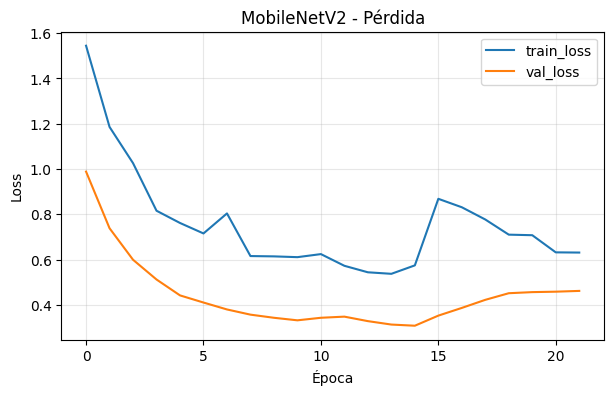

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(history_mobile_df["loss"], label="train_loss")
plt.plot(history_mobile_df["val_loss"], label="val_loss")
plt.title("MobileNetV2 - Pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(figures_path / "mobilenetv2_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
best_mobilenet_model = tf.keras.models.load_model(checkpoint_finetune_path)

test_loss, test_accuracy = best_mobilenet_model.evaluate(test_gen, verbose=1)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.8239 - loss: 0.3498
Test loss: 0.3497809171676636
Test accuracy: 0.8238993883132935


In [12]:
test_gen.reset()

y_prob = best_mobilenet_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

idx_to_class = {
    v: k for k, v in test_gen.class_indices.items()
}

target_names = [
    idx_to_class[i]
    for i in range(len(idx_to_class))
]

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

report_df.to_csv(metrics_path / "mobilenetv2_classification_report.csv")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step


,precision,recall,f1-score,support
benign,0.343750,0.687500,0.458333,16.000000
malignant,0.987179,0.939024,0.962500,82.000000
normal,0.877551,0.704918,0.781818,61.000000
accuracy,0.823899,0.823899,0.823899,0.823899
macro avg,0.736160,0.777147,0.734217,159.000000
weighted avg,0.880373,0.823899,0.842448,159.000000


In [13]:
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

summary_metrics = pd.DataFrame({
    "model": ["MobileNetV2"],
    "test_loss": [test_loss],
    "test_accuracy": [accuracy_score(y_true, y_pred)],
    "macro_precision": [macro_precision],
    "macro_recall": [macro_recall],
    "macro_f1": [macro_f1],
    "weighted_precision": [weighted_precision],
    "weighted_recall": [weighted_recall],
    "weighted_f1": [weighted_f1]
})

display(summary_metrics)

summary_metrics.to_csv(metrics_path / "mobilenetv2_summary_metrics.csv", index=False)

,model,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,MobileNetV2,0.349781,0.823899,0.73616,0.777147,0.734217,0.880373,0.823899,0.842448


In [14]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=target_names,
    columns=target_names
)

display(cm_df)

cm_df.to_csv(metrics_path / "mobilenetv2_confusion_matrix.csv")

,benign,malignant,normal
benign,11,1,4
malignant,3,77,2
normal,18,0,43


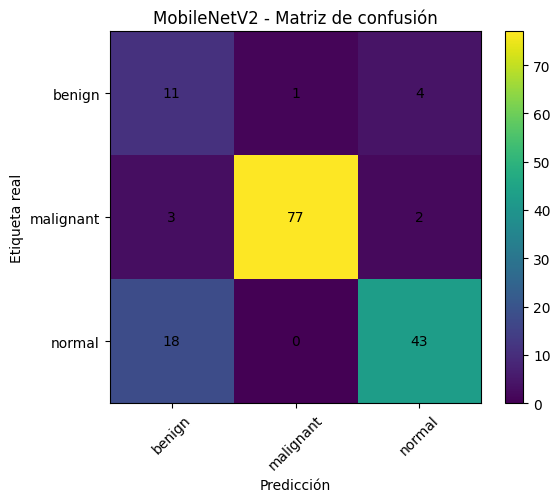

In [15]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("MobileNetV2 - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")

plt.xticks(
    ticks=np.arange(len(target_names)),
    labels=target_names,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(target_names)),
    labels=target_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(figures_path / "mobilenetv2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
predicted_class_counts = pd.Series(
    [idx_to_class[i] for i in y_pred]
).value_counts()

print("Distribución de predicciones:")
print(predicted_class_counts)

Distribución de predicciones:
malignant    78
normal       49
benign       32
Name: count, dtype: int64


In [17]:
probabilities_summary = pd.DataFrame(
    y_prob,
    columns=[idx_to_class[i] for i in range(len(idx_to_class))]
).describe()

display(probabilities_summary)

,benign,malignant,normal
count,1.590000e+02,159.000000,1.590000e+02
mean,2.347940e-01,0.479212,2.859943e-01
std,2.917589e-01,0.473239,3.335991e-01
min,7.887695e-07,0.000004,4.783639e-07
25%,3.580302e-03,0.001503,1.900162e-03
50%,7.341710e-02,0.308091,1.085254e-01
75%,4.125717e-01,0.992058,5.592254e-01
max,9.722310e-01,0.999998,9.968228e-01


In [18]:
predictions_df = test_df.copy().reset_index(drop=True)

predictions_df["true_class"] = [
    idx_to_class[i]
    for i in y_true
]

predictions_df["pred_class"] = [
    idx_to_class[i]
    for i in y_pred
]

predictions_df["confidence"] = np.max(y_prob, axis=1)

predictions_df["correct"] = (
    predictions_df["true_class"] == predictions_df["pred_class"]
)

for class_name, class_idx in test_gen.class_indices.items():
    predictions_df[f"prob_{class_name}"] = y_prob[:, class_idx]

predictions_df.to_csv(metrics_path / "mobilenetv2_test_predictions.csv", index=False)

display(predictions_df.head())

,path,filename,original_class,class,width,height,mode,file_hash,true_class,pred_class,confidence,correct,prob_benign,prob_malignant,prob_normal
0,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (212).jpg,Malignant cases,malignant,801,512,RGB,9a7fc962468f99fd5b06c12eb66fdacb,malignant,malignant,0.999052,True,0.000919,0.999052,0.000029
1,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (519).jpg,Malignant cases,malignant,512,512,RGB,5912a5ce65ed6fc6bcba39272d363d83,malignant,malignant,0.999576,True,0.000392,0.999576,0.000032
2,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Normal case (399).jpg,Normal cases,normal,512,512,RGB,f7f5f6f93bf2beb10f9ff386ad5a6c3e,normal,benign,0.818354,False,0.818354,0.000317,0.181330
3,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Malignant case (266).jpg,Malignant cases,malignant,512,512,RGB,cc27e08e8172e2123ad240c6db095ce8,malignant,malignant,0.997333,True,0.000552,0.997333,0.002115
4,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Normal case (173).jpg,Normal cases,normal,512,512,RGB,17ffe48de6e6dee58a0ca1d81b9d9c6c,normal,normal,0.983490,True,0.015341,0.001169,0.983490
